In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

print("Все библиотеки успешно импортированы")

Все библиотеки успешно импортированы


# Загрузка данных

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
df = pd.read_csv(url, compression='gzip')

print(f"Размер датасета: {df.shape}")
print(f"\n Первые 5 строк:")
display(df.head())

print(f"\n Информация о столбцах:")
df.info()

print(f"\n Статистика:")
display(df.describe())

Размер датасета: (48204, 9)

 Первые 5 строк:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918



 Информация о столбцах:
<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB

 Статистика:


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


# Базовый EDA

Количество дубликатов: 17

 Пропуски в данных:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

 Распределение временных интервалов (в часах):
date_time
1.0     37986
0.0      7629
2.0      2192
3.0       201
4.0        59
5.0        33
6.0        17
8.0        13
10.0       13
9.0        12
Name: count, dtype: int64


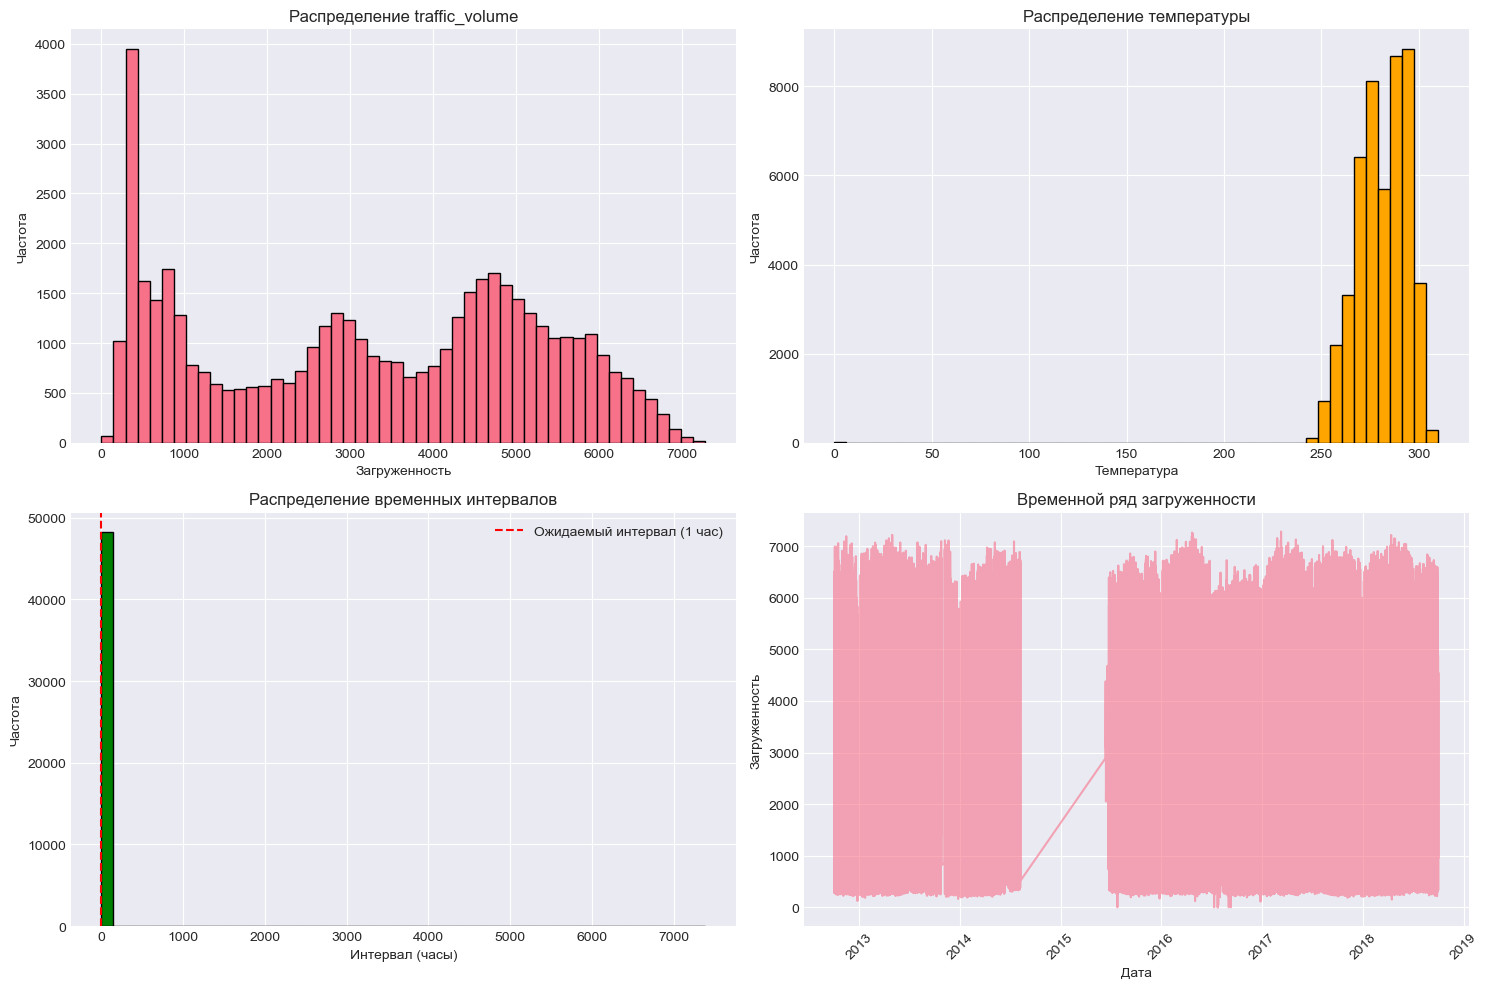

In [5]:
# Проверка на дубликаты
print(f"Количество дубликатов: {df.duplicated().sum()}")

# Проверка на пропуски
print(f"\n Пропуски в данных:")
print(df.isnull().sum())

# Преобразуем дату в datetime
df['date_time'] = pd.to_datetime(df['date_time'])

# Проверка временных интервалов
df_sorted = df.sort_values('date_time')
time_diffs = df_sorted['date_time'].diff().dt.total_seconds() / 3600

print(f"\n Распределение временных интервалов (в часах):")
print(time_diffs.value_counts().head(10))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Распределение traffic_volume
axes[0, 0].hist(df['traffic_volume'], bins=50, edgecolor='black')
axes[0, 0].set_title('Распределение traffic_volume')
axes[0, 0].set_xlabel('Загруженность')
axes[0, 0].set_ylabel('Частота')

# Распределение температуры
axes[0, 1].hist(df['temp'], bins=50, edgecolor='black', color='orange')
axes[0, 1].set_title('Распределение температуры')
axes[0, 1].set_xlabel('Температура')
axes[0, 1].set_ylabel('Частота')

# Временные интервалы
axes[1, 0].hist(time_diffs.dropna(), bins=50, edgecolor='black', color='green')
axes[1, 0].set_title('Распределение временных интервалов')
axes[1, 0].set_xlabel('Интервал (часы)')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].axvline(x=1, color='red', linestyle='--', label='Ожидаемый интервал (1 час)')
axes[1, 0].legend()

# Временной ряд
axes[1, 1].plot(df_sorted['date_time'], df_sorted['traffic_volume'], alpha=0.6)
axes[1, 1].set_title('Временной ряд загруженности')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Загруженность')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Очистка данных

In [6]:
# Отбираем только нужные столбцы
df_clean = df[['date_time', 'holiday', 'temp', 'traffic_volume']].copy()

# Удаляем дубликаты
print(f"До удаления дубликатов: {len(df_clean)} записей")
df_clean = df_clean.drop_duplicates()
print(f"После удаления дубликатов: {len(df_clean)} записей")

# Сортируем по времени
df_clean = df_clean.sort_values('date_time')

# Создаем равномерный временной индекс (каждый час)
start_date = df_clean['date_time'].min()
end_date = df_clean['date_time'].max()
full_date_range = pd.date_range(start=start_date, end=end_date, freq='h')

print(f"\n Период данных: с {start_date} по {end_date}")
print(f"Ожидаемое количество точек: {len(full_date_range)}")
print(f"Фактическое количество точек: {len(df_clean)}")
print(f"Пропущенных точек: {len(full_date_range) - len(df_clean)}")

# Создаем новый DataFrame с полным временным индексом
df_full = pd.DataFrame(index=full_date_range)
df_full.index.name = 'date_time'

# Объединяем с исходными данными
df_full = df_full.join(df_clean.set_index('date_time'))

# Проверяем пропуски после объединения
print(f"\n Пропуски после создания равномерного индекса:")
print(df_full.isnull().sum())

# Заполняем пропуски линейной интерполяцией
df_full['temp'] = df_full['temp'].interpolate(method='linear')
df_full['traffic_volume'] = df_full['traffic_volume'].interpolate(method='linear')
df_full['holiday'] = df_full['holiday'].fillna('None')

print(f"\n После интерполяции:")
print(df_full.isnull().sum())

display(df_full.head(10))

До удаления дубликатов: 48204 записей
После удаления дубликатов: 40653 записей

 Период данных: с 2012-10-02 09:00:00 по 2018-09-30 23:00:00
Ожидаемое количество точек: 52551
Фактическое количество точек: 40653
Пропущенных точек: 11898

 Пропуски после создания равномерного индекса:
holiday           52576
temp              11976
traffic_volume    11976
dtype: int64

 После интерполяции:
holiday           0
temp              0
traffic_volume    0
dtype: int64


,holiday,temp,traffic_volume
date_time,,,
2012-10-02 09:00:00,None,288.28,5545.0
2012-10-02 10:00:00,None,289.36,4516.0
2012-10-02 11:00:00,None,289.58,4767.0
2012-10-02 12:00:00,None,290.13,5026.0
2012-10-02 13:00:00,None,291.14,4918.0
2012-10-02 14:00:00,None,291.72,5181.0
2012-10-02 15:00:00,None,293.17,5584.0
2012-10-02 16:00:00,None,293.86,6015.0
2012-10-02 17:00:00,None,294.14,5791.0


# Детальный EDA

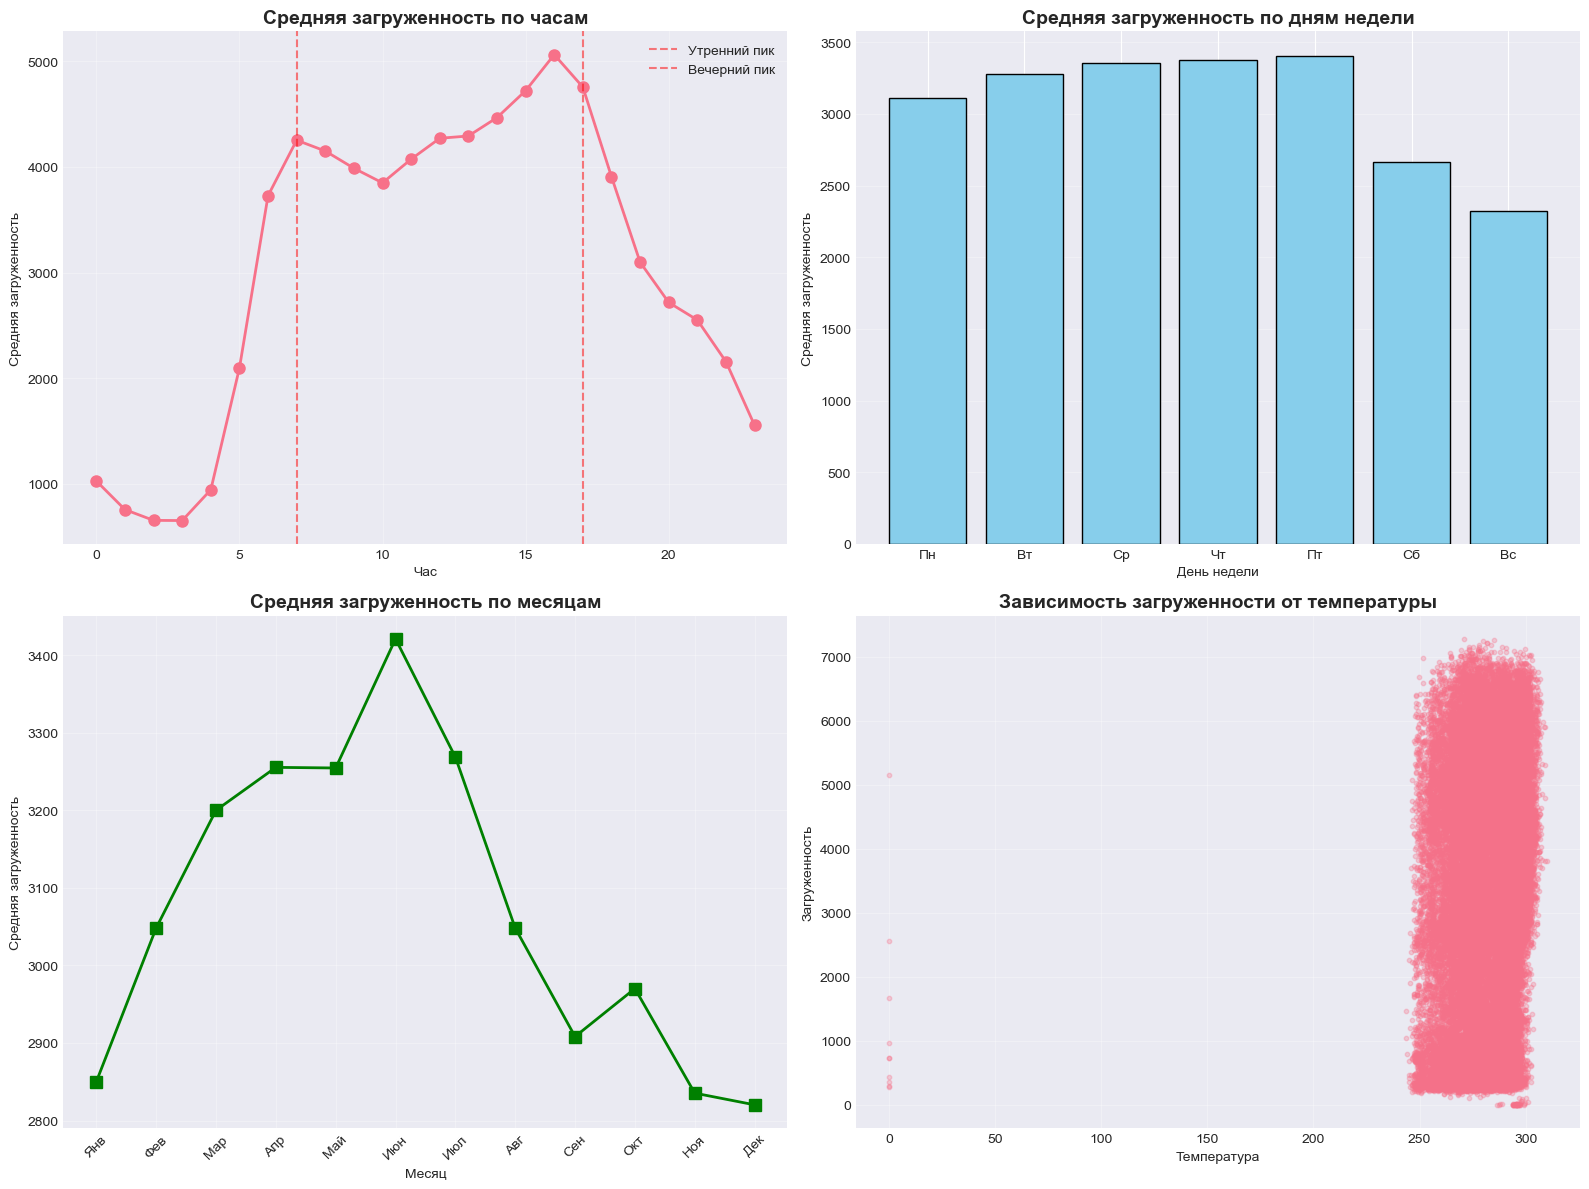

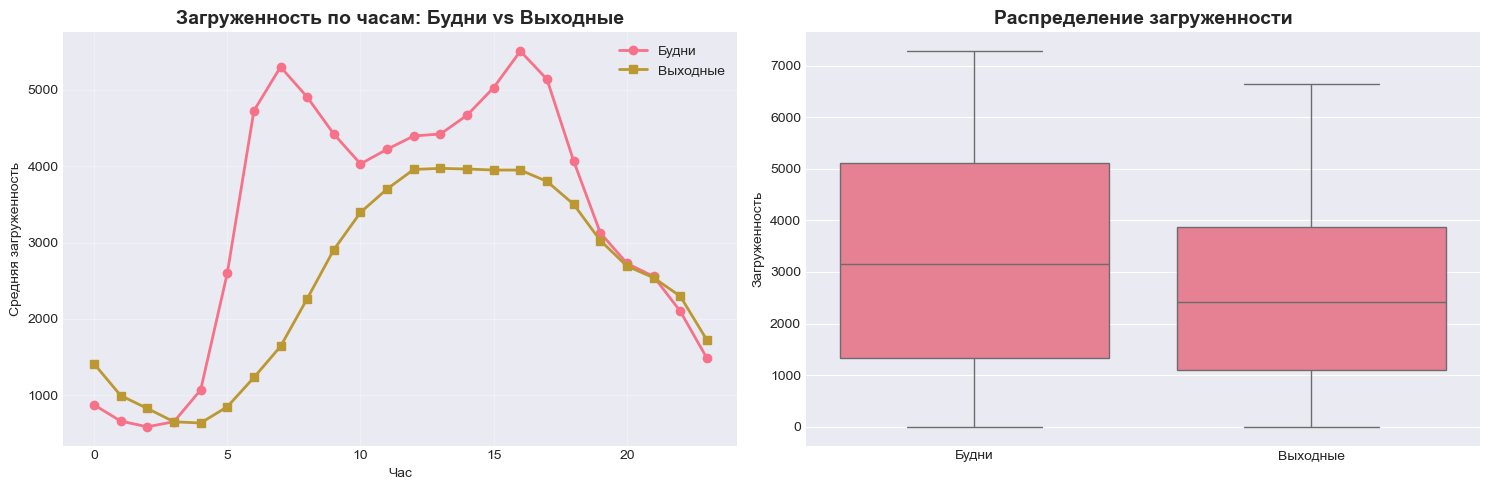

In [7]:
# Создаем дополнительные временные признаки
df_full['hour'] = df_full.index.hour
df_full['dayofweek'] = df_full.index.dayofweek
df_full['month'] = df_full.index.month
df_full['is_weekend'] = df_full['dayofweek'].isin([5, 6]).astype(int)

# Анализ по часам
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Среднее по часам
hourly_mean = df_full.groupby('hour')['traffic_volume'].mean()
axes[0, 0].plot(hourly_mean, marker='o', linewidth=2, markersize=8)
axes[0, 0].set_title('Средняя загруженность по часам', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Час')
axes[0, 0].set_ylabel('Средняя загруженность')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=7, color='red', linestyle='--', alpha=0.5, label='Утренний пик')
axes[0, 0].axvline(x=17, color='red', linestyle='--', alpha=0.5, label='Вечерний пик')
axes[0, 0].legend()

# Среднее по дням недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
daily_mean = df_full.groupby('dayofweek')['traffic_volume'].mean()
axes[0, 1].bar(day_names, daily_mean, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Средняя загруженность по дням недели', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('День недели')
axes[0, 1].set_ylabel('Средняя загруженность')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Среднее по месяцам
month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
monthly_mean = df_full.groupby('month')['traffic_volume'].mean()
axes[1, 0].plot(month_names, monthly_mean, marker='s', linewidth=2, markersize=8, color='green')
axes[1, 0].set_title('Средняя загруженность по месяцам', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Средняя загруженность')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Влияние температуры
axes[1, 1].scatter(df_full['temp'], df_full['traffic_volume'], alpha=0.3, s=10)
axes[1, 1].set_title('Зависимость загруженности от температуры', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Температура')
axes[1, 1].set_ylabel('Загруженность')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ выходных vs будни
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# По часам
weekend_hourly = df_full[df_full['is_weekend'] == 1].groupby('hour')['traffic_volume'].mean()
weekday_hourly = df_full[df_full['is_weekend'] == 0].groupby('hour')['traffic_volume'].mean()

axes[0].plot(weekday_hourly, label='Будни', marker='o', linewidth=2)
axes[0].plot(weekend_hourly, label='Выходные', marker='s', linewidth=2)
axes[0].set_title('Загруженность по часам: Будни vs Выходные', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('Средняя загруженность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
df_full['day_type'] = df_full['is_weekend'].map({0: 'Будни', 1: 'Выходные'})
sns.boxplot(data=df_full, x='day_type', y='traffic_volume', ax=axes[1])
axes[1].set_title('Распределение загруженности', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Загруженность')

plt.tight_layout()
plt.show()

# Разделение на train/test

Период обучения: с 2012-10-02 09:00:00 по 2018-09-16 22:00:00
Количество наблюдений в обучении: 52292

Период тестирования: с 2018-09-16 23:00:00 по 2018-09-30 23:00:00
Количество наблюдений в тесте: 337


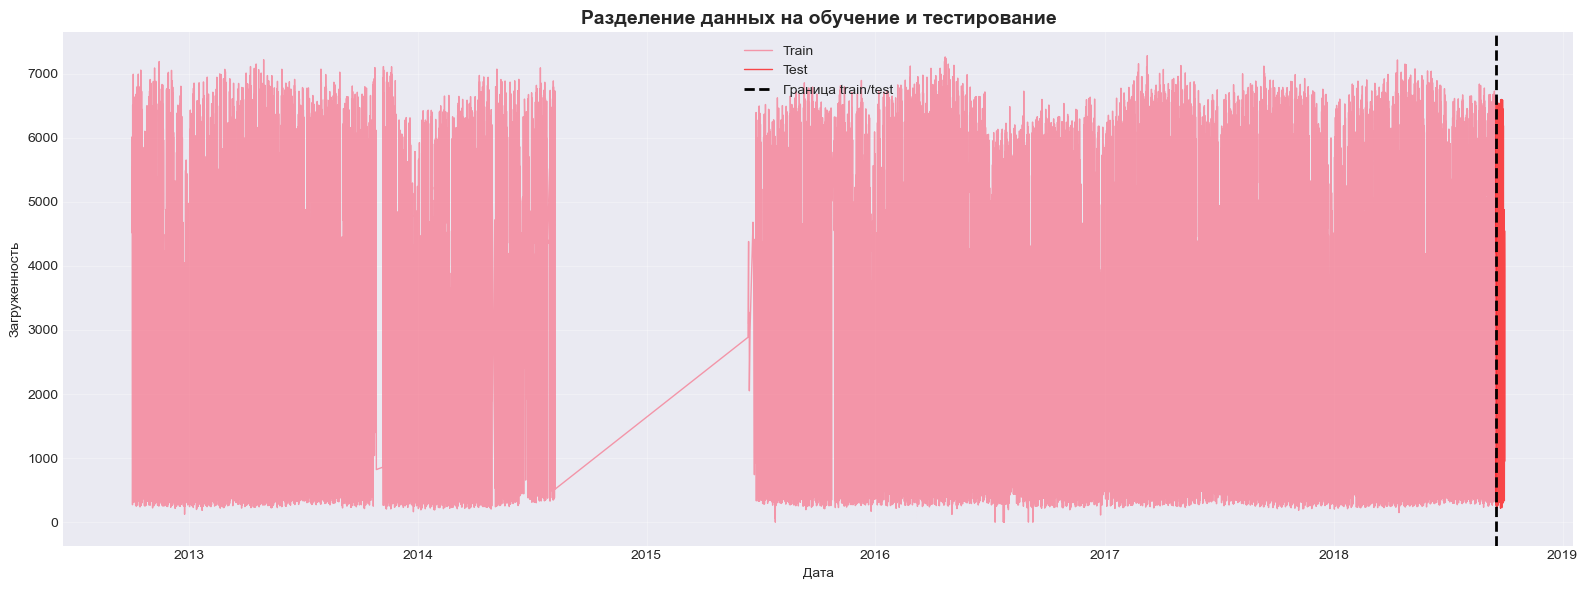


💡 Анализ релевантности исторических данных:
Лаг 24 часов (1 дней): автокорреляция = 0.8552
Лаг 168 часов (7 дней): автокорреляция = 0.8779
Лаг 720 часов (30 дней): автокорреляция = 0.6114
Лаг 8760 часов (365 дней): автокорреляция = 0.1374


In [8]:
# Разделяем данные: последние 2 недели - тест
test_days = 14
test_start = df_full.index[-1] - pd.Timedelta(days=test_days)

train = df_full[df_full.index < test_start]
test = df_full[df_full.index >= test_start]

print(f"Период обучения: с {train.index[0]} по {train.index[-1]}")
print(f"Количество наблюдений в обучении: {len(train)}")
print(f"\nПериод тестирования: с {test.index[0]} по {test.index[-1]}")
print(f"Количество наблюдений в тесте: {len(test)}")

# Визуализация разделения
plt.figure(figsize=(16, 6))
plt.plot(train.index, train['traffic_volume'], label='Train', alpha=0.7, linewidth=1)
plt.plot(test.index, test['traffic_volume'], label='Test', alpha=0.7, linewidth=1, color='red')
plt.axvline(x=test_start, color='black', linestyle='--', linewidth=2, label='Граница train/test')
plt.title('Разделение данных на обучение и тестирование', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Загруженность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ: какие данные релевантны?
print("\n💡 Анализ релевантности исторических данных:")
print("=" * 60)

# Проверяем автокорреляцию на разных лагах
from statsmodels.tsa.stattools import acf

lags_to_check = [24, 24*7, 24*30, 24*365]  # день, неделя, месяц, год
acf_values = acf(train['traffic_volume'], nlags=max(lags_to_check))

for lag in lags_to_check:
    print(f"Лаг {lag} часов ({lag//24} дней): автокорреляция = {acf_values[lag]:.4f}")

# Baseline модель

Baseline модель: среднее по часам и дням недели

Пример значений baseline:


dayofweek  hour
0          0        848.885519
           1        648.666713
           2        580.325622
           3        643.909047
           4       1053.568816
           5       2493.419983
           6       4553.222494
           7       5136.404933
           8       4708.129917
           9       4133.689847
Name: traffic_volume, dtype: float64

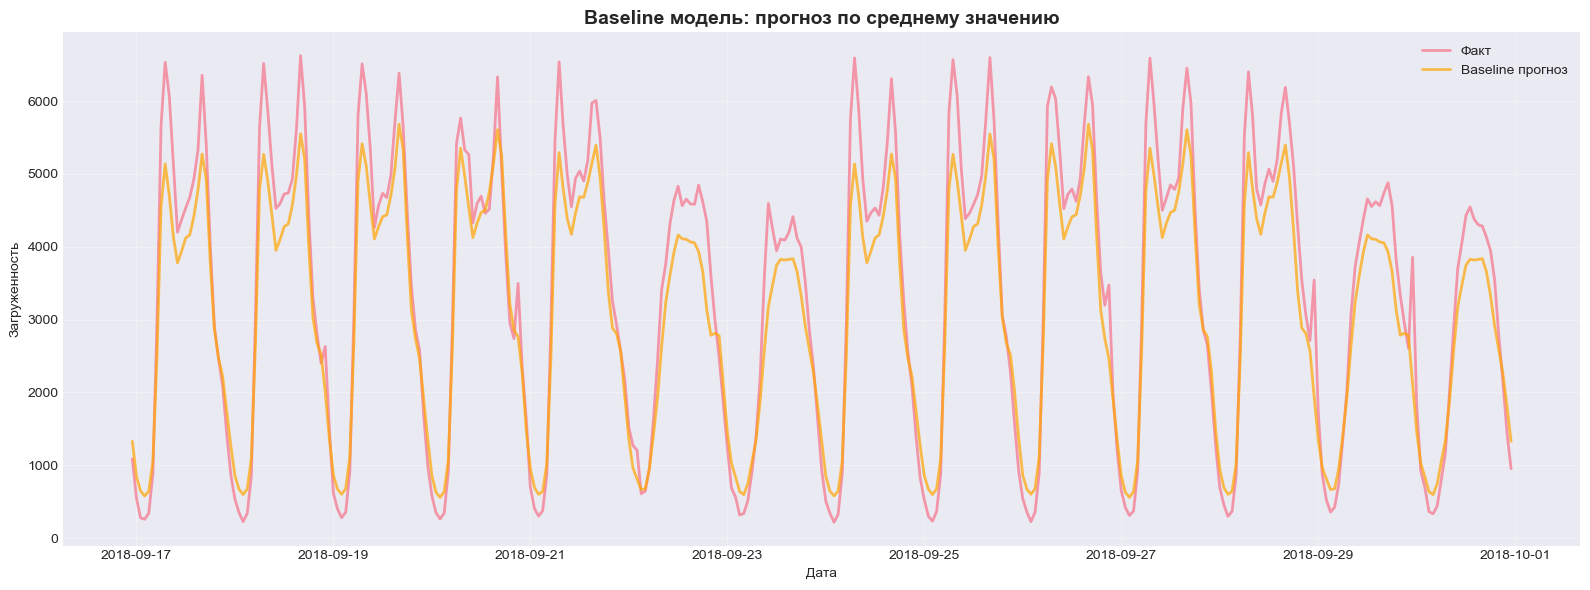


Метрики качества Baseline модели:
MAE (Mean Absolute Error): 457.86
RMSE (Root Mean Squared Error): 553.42
R² (Коэффициент детерминации): 0.9206

Baseline R² = 0.9206


In [9]:
baseline_values = train.groupby(["dayofweek", "hour"])["traffic_volume"].mean()

print("Baseline модель: среднее по часам и дням недели")
print("=" * 60)
print("\nПример значений baseline:")
display(baseline_values.head(10))

# Создаем прогнозы для тестовой выборки
test_baseline = test.copy()
test_baseline['baseline_pred'] = test_baseline.apply(
    lambda row: baseline_values.get((row['dayofweek'], row['hour']), 
                                     train['traffic_volume'].mean()),
    axis=1
)

# Визуализация baseline прогноза
plt.figure(figsize=(16, 6))
plt.plot(test.index, test['traffic_volume'], label='Факт', linewidth=2, alpha=0.7)
plt.plot(test.index, test_baseline['baseline_pred'], label='Baseline прогноз', 
         linewidth=2, alpha=0.7, color='orange')
plt.title('Baseline модель: прогноз по среднему значению', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Загруженность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Расчет метрик
baseline_mae = mean_absolute_error(test['traffic_volume'], test_baseline['baseline_pred'])
baseline_rmse = np.sqrt(mean_squared_error(test['traffic_volume'], test_baseline['baseline_pred']))
baseline_r2 = r2_score(test['traffic_volume'], test_baseline['baseline_pred'])

print("\nМетрики качества Baseline модели:")
print("=" * 60)
print(f"MAE (Mean Absolute Error): {baseline_mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {baseline_rmse:.2f}")
print(f"R² (Коэффициент детерминации): {baseline_r2:.4f}")
print(f"\nBaseline R² = {baseline_r2:.4f}")

# SARIMA модель

Данные для SARIMA: 4320 наблюдений
Период: с 2018-03-20 23:00:00 по 2018-09-16 22:00:00

Тест Дики-Фуллера на стационарность:
ADF статистика: -9.1326
p-value: 0.0000
Критические значения:
   1%: -3.4319
   5%: -2.8622
   10%: -2.5671

 Ряд стационарен (p-value < 0.05)


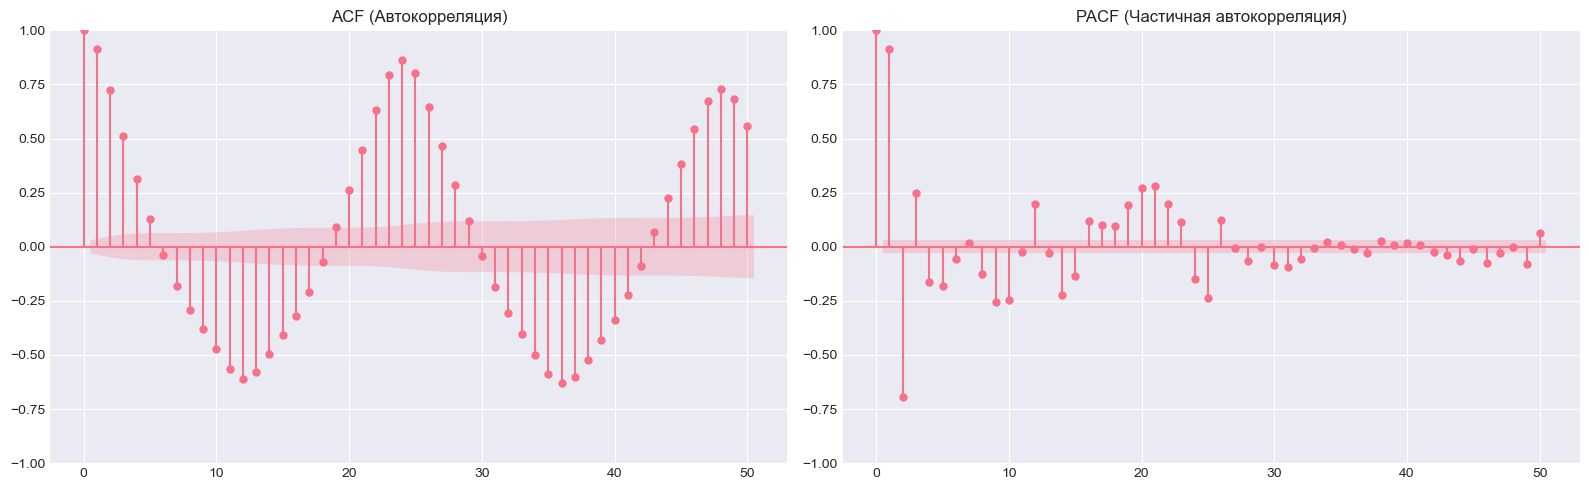


 Обучаем SARIMA модель...

 Модель обучена

 Результаты SARIMA:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1955      0.030     39.511      0.000       1.136       1.255
ar.L2         -0.3984      0.030    -13.424      0.000      -0.457      -0.340
ma.L1         -0.8423      0.067    -12.502      0.000      -0.974      -0.710
ma.L2         -0.1577      0.032     -4.937      0.000      -0.220      -0.095
ar.S.L24       0.2250      0.009     24.352      0.000       0.207       0.243
ma.S.L24      -1.0042      0.009   -106.343      0.000      -1.023      -0.986
sigma2      1.275e+05   7435.485     17.144      0.000    1.13e+05    1.42e+05


In [10]:
months_for_sarima = 6
train_sarima = train.iloc[-months_for_sarima * 30 * 24:]

print(f"Данные для SARIMA: {len(train_sarima)} наблюдений")
print(f"Период: с {train_sarima.index[0]} по {train_sarima.index[-1]}")

# Проверяем стационарность
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_sarima['traffic_volume'])
print(f"\nТест Дики-Фуллера на стационарность:")
print(f"ADF статистика: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Критические значения:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] < 0.05:
    print("\n Ряд стационарен (p-value < 0.05)")
else:
    print("\n Ряд не стационарен, потребуется дифференцирование")

# ACF и PACF для выбора параметров
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(train_sarima['traffic_volume'], lags=50, ax=axes[0])
axes[0].set_title('ACF (Автокорреляция)')
plot_pacf(train_sarima['traffic_volume'], lags=50, ax=axes[1])
axes[1].set_title('PACF (Частичная автокорреляция)')
plt.tight_layout()
plt.show()

print("\n Обучаем SARIMA модель...")

# SARIMA с дневной сезонностью (m=24)
model_sarima = SARIMAX(
    train_sarima['traffic_volume'],
    order=(2, 1, 2),              # (p, d, q) - параметры ARIMA
    seasonal_order=(1, 1, 1, 24),  # (P, D, Q, m) - сезонность (24 часа)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Обучение модели
results_sarima = model_sarima.fit(disp=False)

print("\n Модель обучена")
print("\n Результаты SARIMA:")
print(results_sarima.summary().tables[1])

# Прогноз SARIMA

Метрики качества SARIMA модели:
MAE: 571.84
RMSE: 860.46
R²: 0.8080

Сравнение с Baseline:
Метрика              Baseline        SARIMA          Улучшение      
------------------------------------------------------------
MAE                  457.86          571.84          -24.89%
RMSE                 553.42          860.46          -55.48%
R²                   0.9206          0.8080          -12.23%


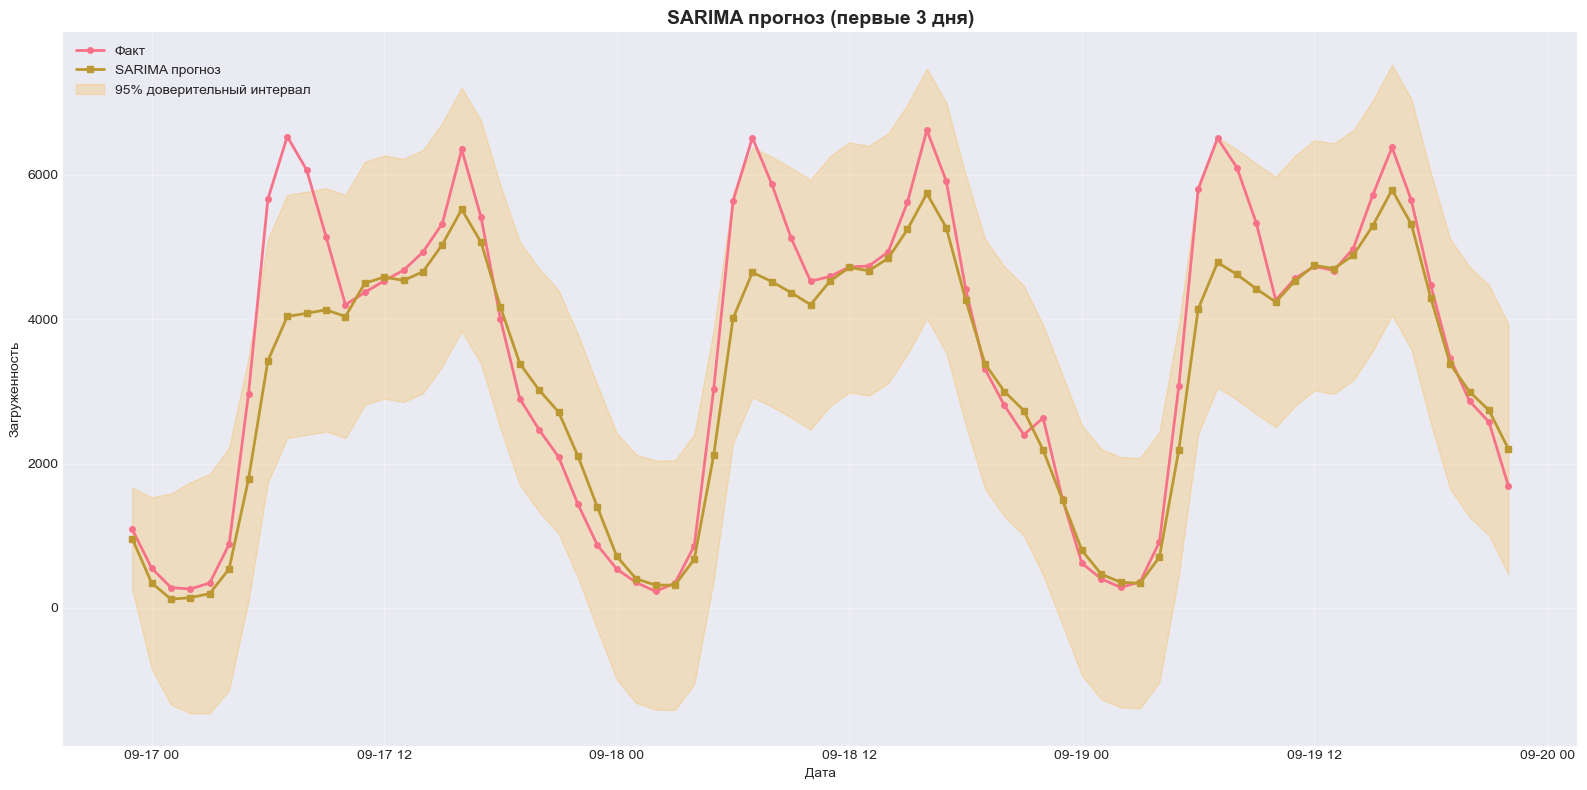

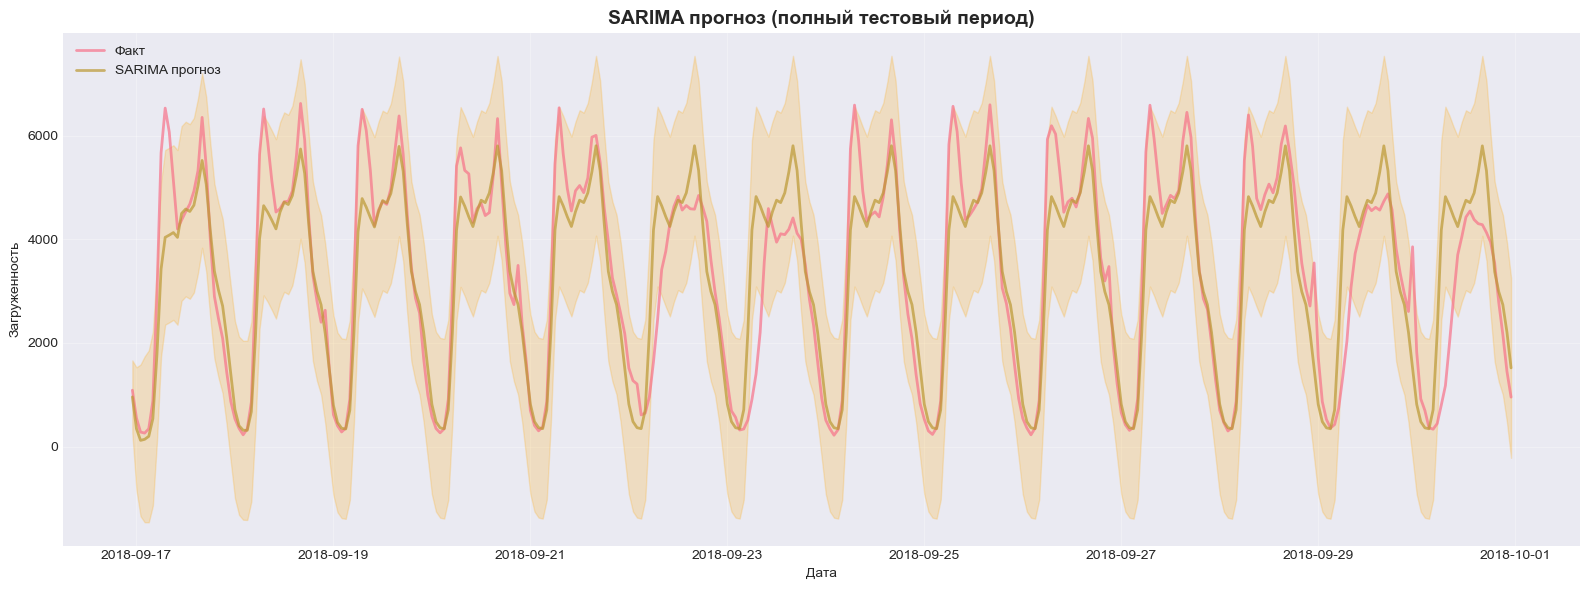

In [11]:
# Прогноз на тестовый период
forecast_steps = len(test)
forecast_sarima = results_sarima.get_forecast(steps=forecast_steps)

# Получаем прогнозы и доверительные интервалы
sarima_pred = forecast_sarima.predicted_mean
sarima_conf_int = forecast_sarima.conf_int(alpha=0.05)

# Расчет метрик
sarima_mae = mean_absolute_error(test['traffic_volume'], sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test['traffic_volume'], sarima_pred))
sarima_r2 = r2_score(test['traffic_volume'], sarima_pred)

print("Метрики качества SARIMA модели:")
print("=" * 60)
print(f"MAE: {sarima_mae:.2f}")
print(f"RMSE: {sarima_rmse:.2f}")
print(f"R²: {sarima_r2:.4f}")

# Сравнение с baseline
print("\nСравнение с Baseline:")
print("=" * 60)
print(f"{'Метрика':<20} {'Baseline':<15} {'SARIMA':<15} {'Улучшение':<15}")
print("-" * 60)
print(f"{'MAE':<20} {baseline_mae:<15.2f} {sarima_mae:<15.2f} {((baseline_mae - sarima_mae) / baseline_mae * 100):.2f}%")
print(f"{'RMSE':<20} {baseline_rmse:<15.2f} {sarima_rmse:<15.2f} {((baseline_rmse - sarima_rmse) / baseline_rmse * 100):.2f}%")
print(f"{'R²':<20} {baseline_r2:<15.4f} {sarima_r2:<15.4f} {((sarima_r2 - baseline_r2) / baseline_r2 * 100):.2f}%")

# Визуализация прогноза
plt.figure(figsize=(16, 8))

# Первые 3 дня для детального просмотра
plot_days = 3
plot_hours = plot_days * 24

plt.plot(test.index[:plot_hours], test['traffic_volume'][:plot_hours], 
         label='Факт', linewidth=2, marker='o', markersize=4)
plt.plot(test.index[:plot_hours], sarima_pred[:plot_hours], 
         label='SARIMA прогноз', linewidth=2, marker='s', markersize=4)
plt.fill_between(test.index[:plot_hours],
                 sarima_conf_int.iloc[:plot_hours, 0],
                 sarima_conf_int.iloc[:plot_hours, 1],
                 alpha=0.2, color='orange', label='95% доверительный интервал')

plt.title(f'SARIMA прогноз (первые {plot_days} дня)', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Загруженность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Полный тестовый период
plt.figure(figsize=(16, 6))
plt.plot(test.index, test['traffic_volume'], label='Факт', linewidth=2, alpha=0.7)
plt.plot(test.index, sarima_pred, label='SARIMA прогноз', linewidth=2, alpha=0.7)
plt.fill_between(test.index,
                 sarima_conf_int.iloc[:, 0],
                 sarima_conf_int.iloc[:, 1],
                 alpha=0.2, color='orange')
plt.title('SARIMA прогноз (полный тестовый период)', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Загруженность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Прогноз температуры для SARIMAX

Прогнозирование температуры с помощью SARIMA...
Прогноз температуры готов!


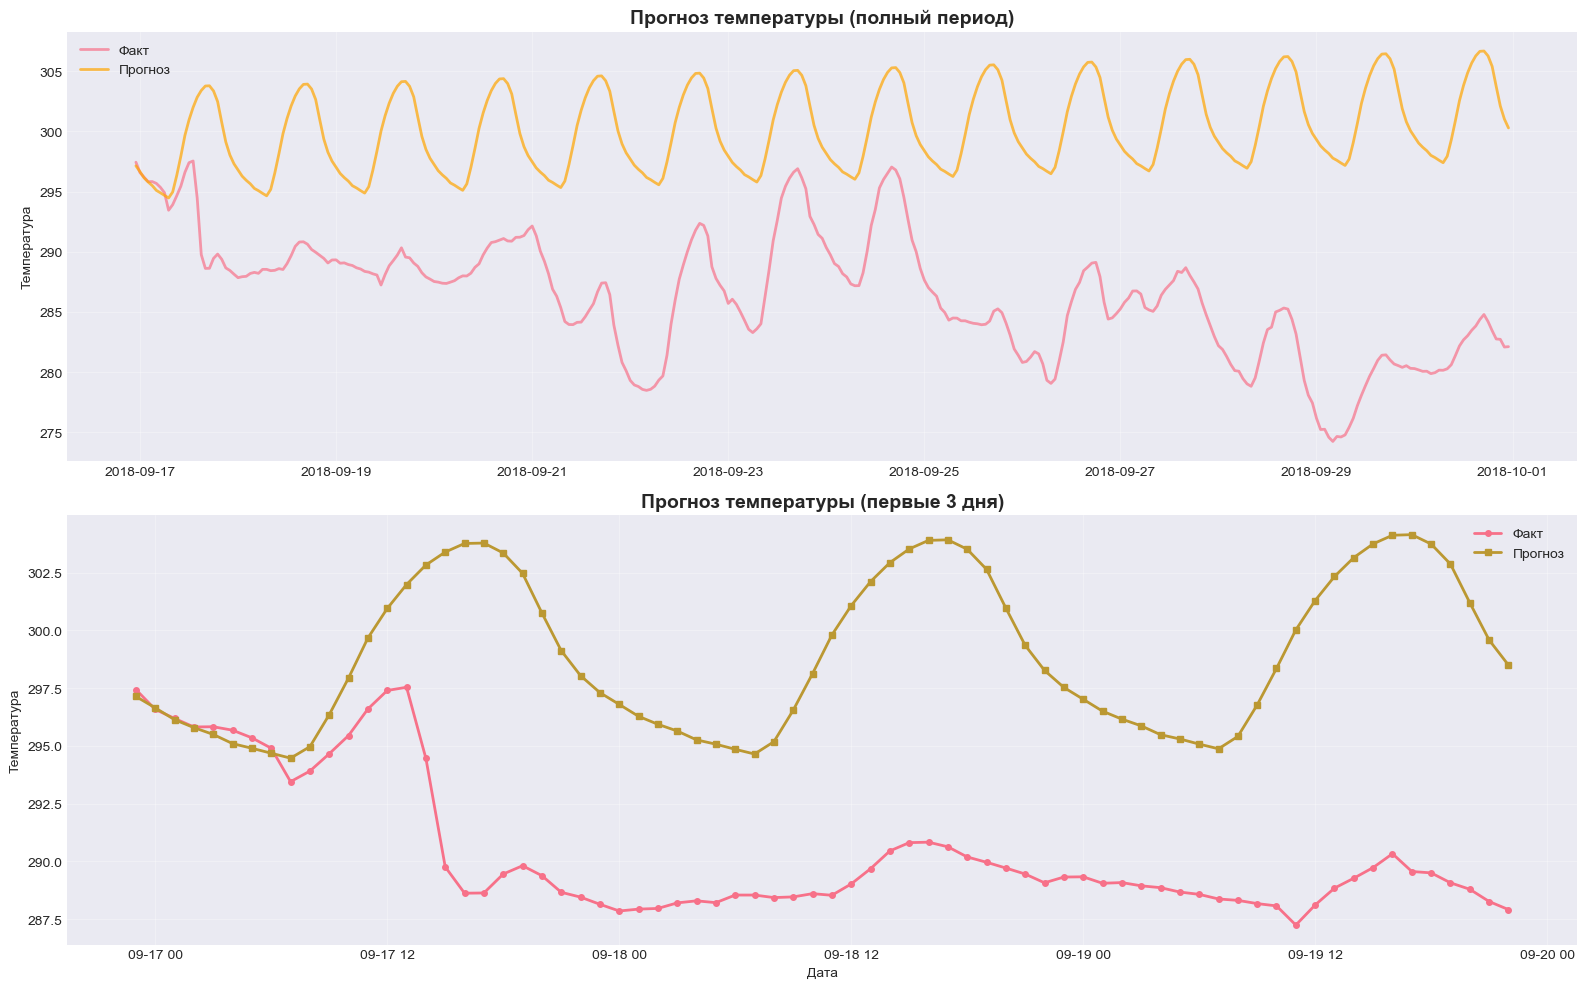


 Метрики прогноза температуры:
MAE: 13.80
RMSE: 14.90
R²: -7.8873


In [12]:
# Прогнозируем температуру отдельно с помощью SARIMA
print("Прогнозирование температуры с помощью SARIMA...")

model_temp = SARIMAX(
    train_sarima['temp'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_temp = model_temp.fit(disp=False)
temp_forecast = results_temp.get_forecast(steps=forecast_steps)
temp_pred = temp_forecast.predicted_mean

print("Прогноз температуры готов!")

# Визуализация прогноза температуры
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Полный период
axes[0].plot(test.index, test['temp'], label='Факт', linewidth=2, alpha=0.7)
axes[0].plot(test.index, temp_pred, label='Прогноз', linewidth=2, alpha=0.7, color='orange')
axes[0].set_title('Прогноз температуры (полный период)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Температура')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Первые 3 дня
plot_hours = 3 * 24
axes[1].plot(test.index[:plot_hours], test['temp'][:plot_hours], 
             label='Факт', linewidth=2, marker='o', markersize=4)
axes[1].plot(test.index[:plot_hours], temp_pred[:plot_hours], 
             label='Прогноз', linewidth=2, marker='s', markersize=4)
axes[1].set_title(f'Прогноз температуры (первые 3 дня)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Температура')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Метрики прогноза температуры
temp_mae = mean_absolute_error(test['temp'], temp_pred)
temp_rmse = np.sqrt(mean_squared_error(test['temp'], temp_pred))
temp_r2 = r2_score(test['temp'], temp_pred)

print(f"\n Метрики прогноза температуры:")
print(f"MAE: {temp_mae:.2f}")
print(f"RMSE: {temp_rmse:.2f}")
print(f"R²: {temp_r2:.4f}")

# SARIMAX с экзогенной переменной

Обучаем SARIMAX модель с температурой как экзогенным признаком...
SARIMAX модель обучена

 Метрики качества SARIMAX модели:
MAE: 1073.41
RMSE: 1243.34
R²: 0.5991

 Сравнение всех моделей:
Модель               MAE             RMSE            R²             
--------------------------------------------------------------------------------
Baseline             457.86          553.42          0.9206         
SARIMA               571.84          860.46          0.8080         
SARIMAX              1073.41         1243.34         0.5991         


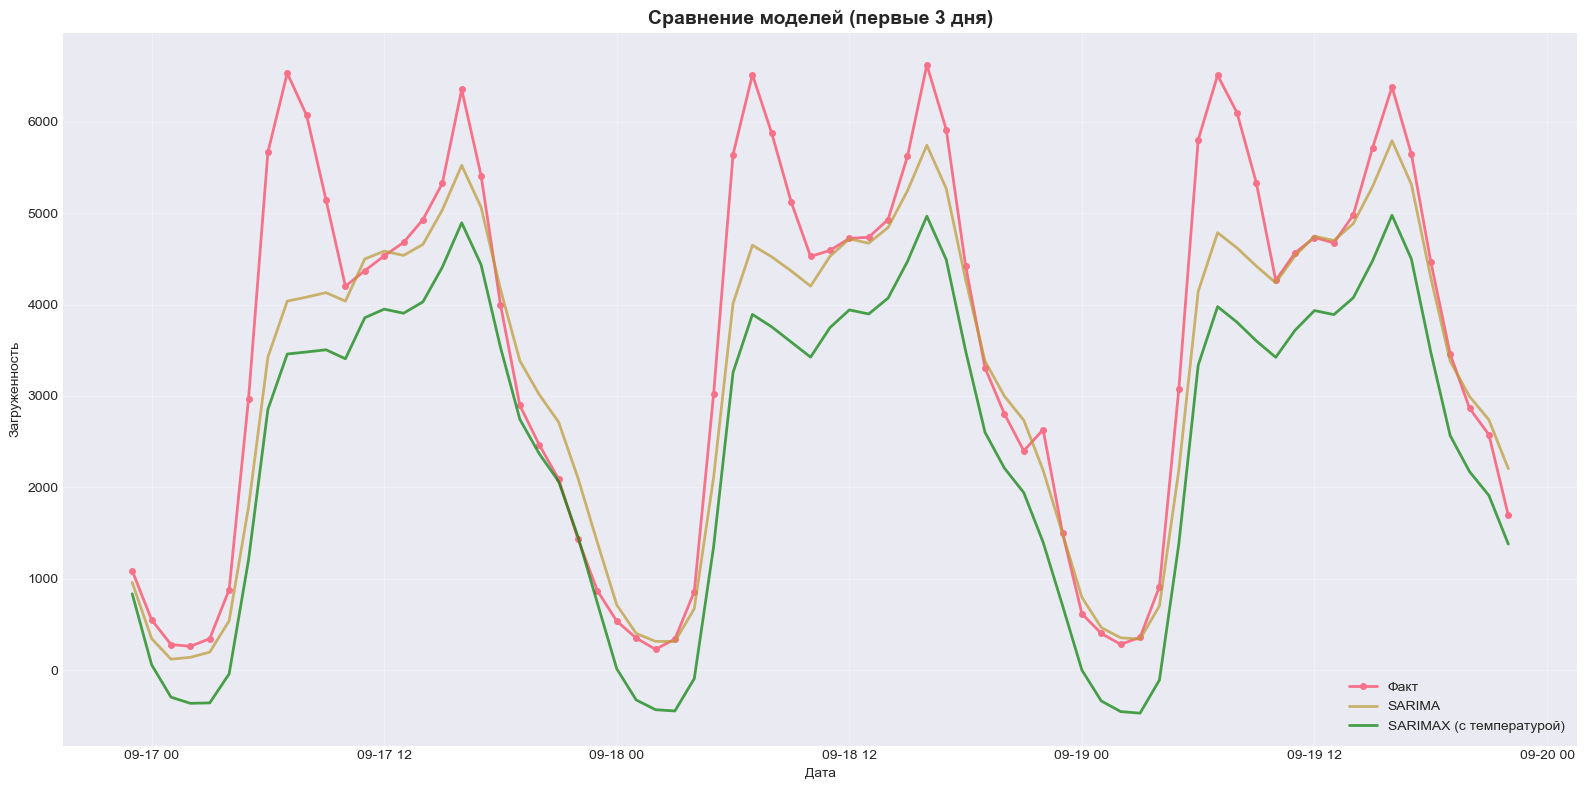

In [13]:
print("Обучаем SARIMAX модель с температурой как экзогенным признаком...")

# SARIMAX с температурой
model_sarimax = SARIMAX(
    train_sarima['traffic_volume'],
    exog=train_sarima['temp'],
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarimax = model_sarimax.fit(disp=False)

print("SARIMAX модель обучена")

# Прогноз с использованием предсказанной температуры
forecast_sarimax = results_sarimax.get_forecast(
    steps=forecast_steps,
    exog=temp_pred.values.reshape(-1, 1)
)

sarimax_pred = forecast_sarimax.predicted_mean
sarimax_conf_int = forecast_sarimax.conf_int(alpha=0.05)

# Метрики
sarimax_mae = mean_absolute_error(test['traffic_volume'], sarimax_pred)
sarimax_rmse = np.sqrt(mean_squared_error(test['traffic_volume'], sarimax_pred))
sarimax_r2 = r2_score(test['traffic_volume'], sarimax_pred)

print("\n Метрики качества SARIMAX модели:")
print("=" * 60)
print(f"MAE: {sarimax_mae:.2f}")
print(f"RMSE: {sarimax_rmse:.2f}")
print(f"R²: {sarimax_r2:.4f}")

# Сравнение всех моделей
print("\n Сравнение всех моделей:")
print("=" * 80)
print(f"{'Модель':<20} {'MAE':<15} {'RMSE':<15} {'R²':<15}")
print("-" * 80)
print(f"{'Baseline':<20} {baseline_mae:<15.2f} {baseline_rmse:<15.2f} {baseline_r2:<15.4f}")
print(f"{'SARIMA':<20} {sarima_mae:<15.2f} {sarima_rmse:<15.2f} {sarima_r2:<15.4f}")
print(f"{'SARIMAX':<20} {sarimax_mae:<15.2f} {sarimax_rmse:<15.2f} {sarimax_r2:<15.4f}")

# Визуализация
plt.figure(figsize=(16, 8))
plot_hours = 3 * 24

plt.plot(test.index[:plot_hours], test['traffic_volume'][:plot_hours], 
         label='Факт', linewidth=2, marker='o', markersize=4)
plt.plot(test.index[:plot_hours], sarima_pred[:plot_hours], 
         label='SARIMA', linewidth=2, alpha=0.7)
plt.plot(test.index[:plot_hours], sarimax_pred[:plot_hours], 
         label='SARIMAX (с температурой)', linewidth=2, alpha=0.7, color='green')

plt.title(f'Сравнение моделей (первые 3 дня)', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Загруженность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Machine Learning модель (Random Forest)

Создаем признаки для ML модели...
Создано признаков: 21
Размер обучающей выборки: 52124

Обучение Random Forest...
Модель обучена!

 Важность признаков (топ-10):


,feature,importance
11,lag_1,0.752397
7,hour_cos,0.116765
13,lag_168,0.063133
17,diff_1,0.055451
12,lag_24,0.007863
18,diff_24,0.002527
6,hour_sin,0.001555
0,hour,0.000114
14,rolling_mean_24,0.000064
16,rolling_mean_168,0.000042


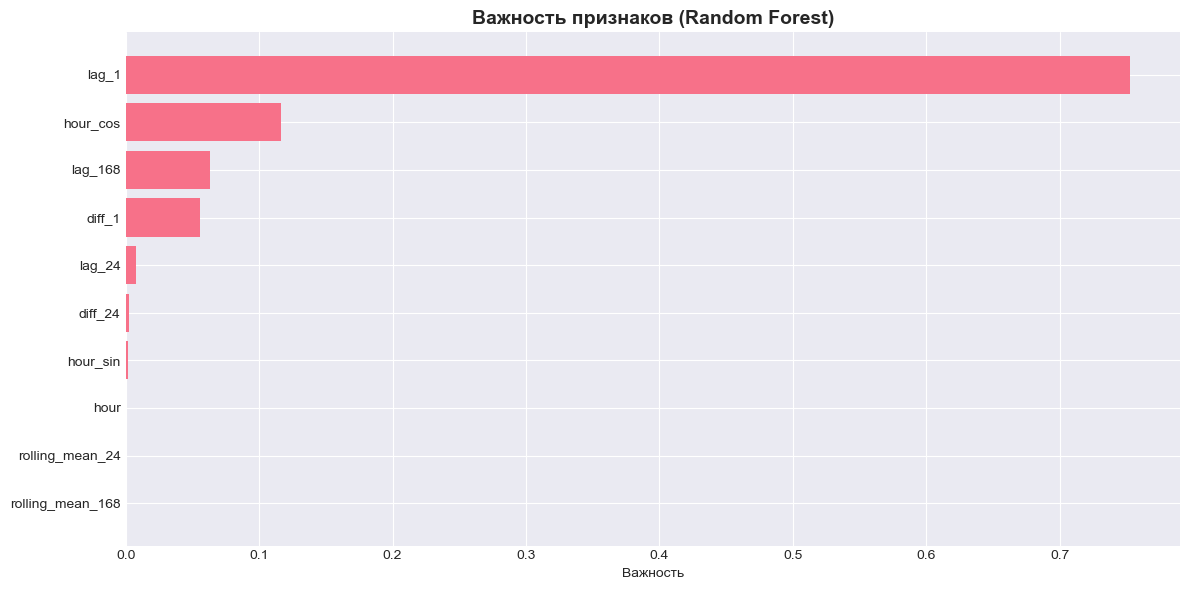

In [14]:
print("Создаем признаки для ML модели...")

# Функция для создания признаков
def create_features(df, is_train=True):
    """Создание признаков для ML модели"""
    df = df.copy()
    
    # Временные признаки
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['is_holiday'] = (df['holiday'] != 'None').astype(int)
    
    # Циклические признаки (sin/cos для часа и дня недели)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # Лаги (предыдущие значения)
    if is_train:
        df['lag_1'] = df['traffic_volume'].shift(1)      # предыдущий час
        df['lag_24'] = df['traffic_volume'].shift(24)    # предыдущий день
        df['lag_168'] = df['traffic_volume'].shift(168)  # предыдущая неделя
        
        # Скользящие статистики
        df['rolling_mean_24'] = df['traffic_volume'].shift(1).rolling(window=24).mean()
        df['rolling_std_24'] = df['traffic_volume'].shift(1).rolling(window=24).std()
        df['rolling_mean_168'] = df['traffic_volume'].shift(1).rolling(window=168).mean()
        
        # Разности
        df['diff_1'] = df['traffic_volume'].diff(1)
        df['diff_24'] = df['traffic_volume'].diff(24)
    
    return df

# Создаем признаки для train
train_ml = create_features(train)

# Удаляем пропуски, возникшие из-за лагов
train_ml = train_ml.dropna()

print(f"Создано признаков: {train_ml.shape[1] - 1}")
print(f"Размер обучающей выборки: {len(train_ml)}")

# Определяем признаки и целевую переменную
feature_cols = ['hour', 'dayofweek', 'month', 'day', 'is_weekend', 'is_holiday',
                'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos',
                'temp', 'lag_1', 'lag_24', 'lag_168',
                'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168',
                'diff_1', 'diff_24']

X_train = train_ml[feature_cols]
y_train = train_ml['traffic_volume']

print(f"\nОбучение Random Forest...")

# Обучаем Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Модель обучена!")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Важность признаков (топ-10):")
display(feature_importance.head(10))

plt.figure(figsize=(12, 6))
plt.barh(feature_importance['feature'][:10][::-1], 
         feature_importance['importance'][:10][::-1])
plt.title('Важность признаков (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# Прогноз ML модели (итеративный)

In [15]:
print("Создаем прогноз для тестовой выборки...")

test_ml = test.copy()
predictions = []

last_values = train['traffic_volume'].tail(168).tolist()  # последняя неделя
last_temp = test['temp'].values

for i in range(len(test)):
    # Создаем признаки для текущего момента
    current_time = test.index[i]
    
    features = {
        'hour': current_time.hour,
        'dayofweek': current_time.dayofweek,
        'month': current_time.month,
        'day': current_time.day,
        'is_weekend': int(current_time.dayofweek in [5, 6]),
        'is_holiday': int(test_ml.iloc[i]['holiday'] != 'None'),
        'hour_sin': np.sin(2 * np.pi * current_time.hour / 24),
        'hour_cos': np.cos(2 * np.pi * current_time.hour / 24),
        'dayofweek_sin': np.sin(2 * np.pi * current_time.dayofweek / 7),
        'dayofweek_cos': np.cos(2 * np.pi * current_time.dayofweek / 7),
        'temp': last_temp[i],
        'lag_1': last_values[-1],
        'lag_24': last_values[-24],
        'lag_168': last_values[-168] if len(last_values) >= 168 else last_values[0],
        'rolling_mean_24': np.mean(last_values[-24:]),
        'rolling_std_24': np.std(last_values[-24:]),
        'rolling_mean_168': np.mean(last_values[-168:]) if len(last_values) >= 168 else np.mean(last_values),
        'diff_1': last_values[-1] - last_values[-2] if len(last_values) >= 2 else 0,
        'diff_24': last_values[-1] - last_values[-24] if len(last_values) >= 24 else 0
    }
    
    # Прогноз
    X_pred = pd.DataFrame([features])[feature_cols]
    pred = rf_model.predict(X_pred)[0]
    predictions.append(pred)
    
    # Обновляем последние значения
    last_values.append(pred)
    if len(last_values) > 500:  # Ограничиваем размер
        last_values = last_values[-500:]

rf_pred = np.array(predictions)

# Метрики
rf_mae = mean_absolute_error(test['traffic_volume'], rf_pred)
rf_rmse = np.sqrt(mean_squared_error(test['traffic_volume'], rf_pred))
rf_r2 = r2_score(test['traffic_volume'], rf_pred)

print("\n Метрики качества Random Forest:")
print("=" * 60)
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²: {rf_r2:.4f}")

# Финальное сравнение всех моделей
print("\n" + "=" * 80)
print(" ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 80)
print(f"{'Модель':<25} {'MAE':<15} {'RMSE':<15} {'R²':<15}")
print("-" * 80)
print(f"{'Baseline (среднее)':<25} {baseline_mae:<15.2f} {baseline_rmse:<15.2f} {baseline_r2:<15.4f}")
print(f"{'SARIMA':<25} {sarima_mae:<15.2f} {sarima_rmse:<15.2f} {sarima_r2:<15.4f}")
print(f"{'SARIMAX (с температурой)':<25} {sarimax_mae:<15.2f} {sarimax_rmse:<15.2f} {sarimax_r2:<15.4f}")
print(f"{'Random Forest':<25} {rf_mae:<15.2f} {rf_rmse:<15.2f} {rf_r2:<15.4f}")
print("=" * 80)

# Определяем лучшую модель
models = {
    'Baseline': (baseline_mae, baseline_rmse, baseline_r2),
    'SARIMA': (sarima_mae, sarima_rmse, sarima_r2),
    'SARIMAX': (sarimax_mae, sarimax_rmse, sarimax_r2),
    'Random Forest': (rf_mae, rf_rmse, rf_r2)
}

best_model = min(models.items(), key=lambda x: x[1][0])  # по MAE
print(f"\n Лучшая модель по MAE: {best_model[0]} (MAE = {best_model[1][0]:.2f})")

Создаем прогноз для тестовой выборки...

 Метрики качества Random Forest:
MAE: 2603.71
RMSE: 3126.45
R²: -1.5346

 ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
Модель                    MAE             RMSE            R²             
--------------------------------------------------------------------------------
Baseline (среднее)        457.86          553.42          0.9206         
SARIMA                    571.84          860.46          0.8080         
SARIMAX (с температурой)  1073.41         1243.34         0.5991         
Random Forest             2603.71         3126.45         -1.5346        

 Лучшая модель по MAE: Baseline (MAE = 457.86)


# Визуализация всех прогнозов

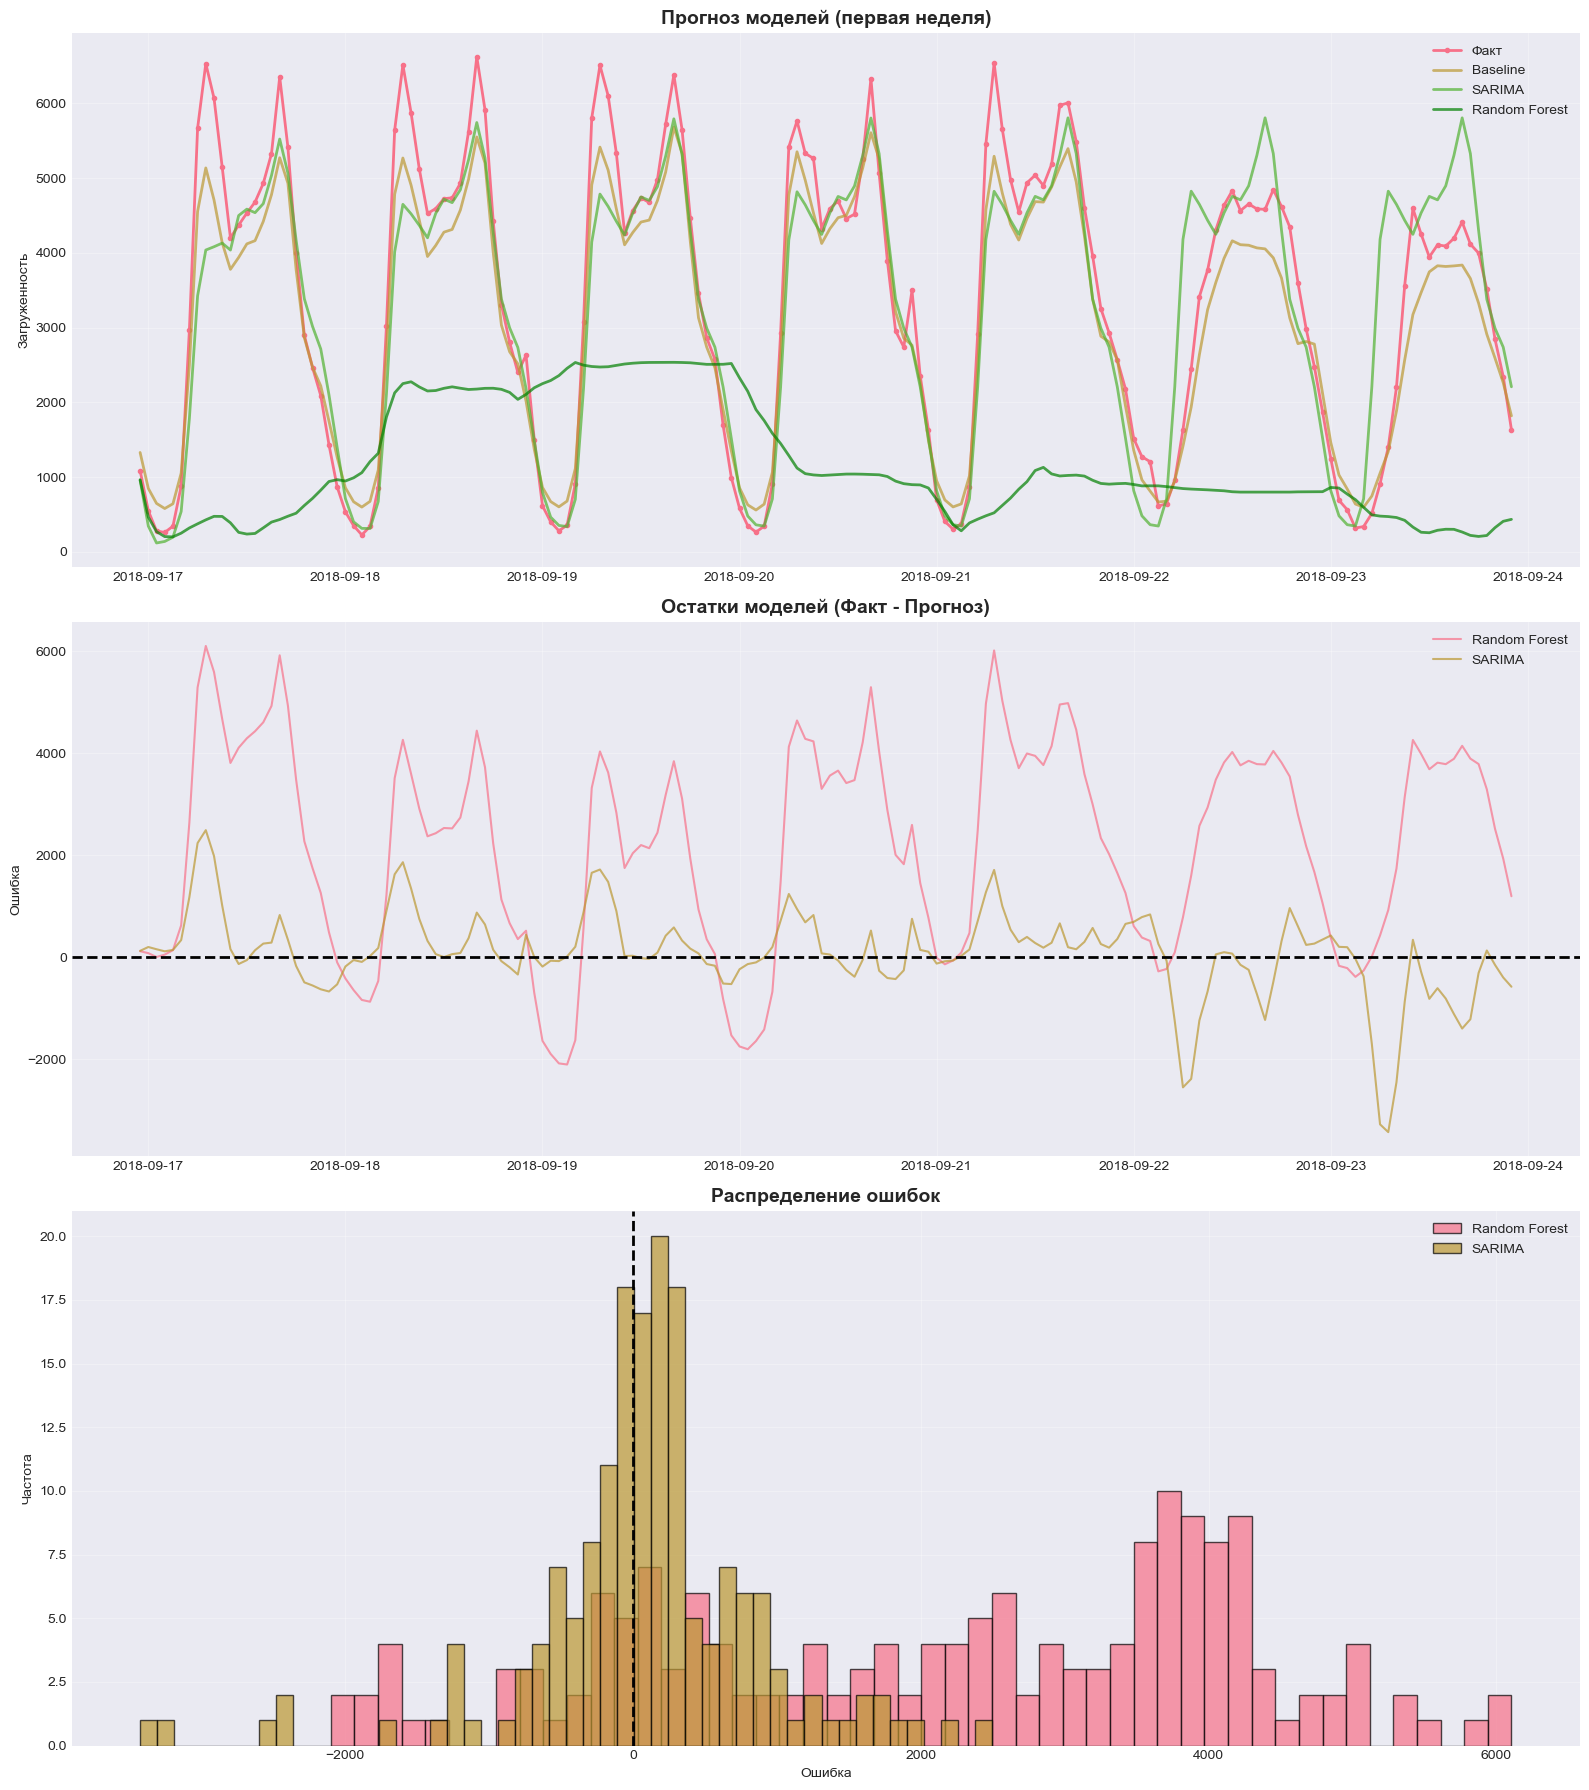

In [16]:
# Визуализация всех моделей
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# Полный тестовый период
plot_hours = 7 * 24  # первая неделя

# Первая неделя
axes[0].plot(test.index[:plot_hours], test['traffic_volume'][:plot_hours], 
             label='Факт', linewidth=2, marker='o', markersize=3)
axes[0].plot(test.index[:plot_hours], test_baseline['baseline_pred'][:plot_hours], 
             label='Baseline', linewidth=2, alpha=0.7)
axes[0].plot(test.index[:plot_hours], sarima_pred[:plot_hours], 
             label='SARIMA', linewidth=2, alpha=0.7)
axes[0].plot(test.index[:plot_hours], rf_pred[:plot_hours], 
             label='Random Forest', linewidth=2, alpha=0.7, color='green')
axes[0].set_title('Прогноз моделей (первая неделя)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Загруженность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Остатки (ошибки)
axes[1].plot(test.index[:plot_hours], 
             test['traffic_volume'][:plot_hours] - rf_pred[:plot_hours],
             label='Random Forest', alpha=0.7)
axes[1].plot(test.index[:plot_hours], 
             test['traffic_volume'][:plot_hours] - sarima_pred[:plot_hours],
             label='SARIMA', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1].set_title('Остатки моделей (Факт - Прогноз)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Ошибка')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Распределение ошибок
axes[2].hist(test['traffic_volume'][:plot_hours] - rf_pred[:plot_hours], 
             bins=50, alpha=0.7, label='Random Forest', edgecolor='black')
axes[2].hist(test['traffic_volume'][:plot_hours] - sarima_pred[:plot_hours], 
             bins=50, alpha=0.7, label='SARIMA', edgecolor='black')
axes[2].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[2].set_title('Распределение ошибок', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Ошибка')
axes[2].set_ylabel('Частота')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Финальный прогноз на следующую неделю с доверительными интервалами

In [ ]:
print("Создаем финальный прогноз на следующую неделю...")

# Используем лучшую модель (Random Forest) для финального прогноза
# Прогноз на 7 дней вперед (168 часов)

forecast_days = 7
forecast_hours = forecast_days * 24

# Получаем последние данные
last_date = df_full.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), 
                                periods=forecast_hours, freq='h')

print(f"Прогноз с {forecast_dates[0]} по {forecast_dates[-1]}")

# Итеративный прогноз
final_predictions = []
last_values = df_full['traffic_volume'].tail(168).tolist()
last_temp = df_full['temp'].tail(forecast_hours).tolist()

for i in range(forecast_hours):
    current_time = forecast_dates[i]
    
    features = {
        'hour': current_time.hour,
        'dayofweek': current_time.dayofweek,
        'month': current_time.month,
        'day': current_time.day,
        'is_weekend': int(current_time.dayofweek in [5, 6]),
        'is_holiday': 0,  # предполагаем, что праздников нет
        'hour_sin': np.sin(2 * np.pi * current_time.hour / 24),
        'hour_cos': np.cos(2 * np.pi * current_time.hour / 24),
        'dayofweek_sin': np.sin(2 * np.pi * current_time.dayofweek / 7),
        'dayofweek_cos': np.cos(2 * np.pi * current_time.dayofweek / 7),
        'temp': last_temp[i] if i < len(last_temp) else last_temp[-1],
        'lag_1': last_values[-1],
        'lag_24': last_values[-24],
        'lag_168': last_values[-168] if len(last_values) >= 168 else last_values[0],
        'rolling_mean_24': np.mean(last_values[-24:]),
        'rolling_std_24': np.std(last_values[-24:]),
        'rolling_mean_168': np.mean(last_values[-168:]) if len(last_values) >= 168 else np.mean(last_values),
        'diff_1': last_values[-1] - last_values[-2] if len(last_values) >= 2 else 0,
        'diff_24': last_values[-1] - last_values[-24] if len(last_values) >= 24 else 0
    }
    
    X_pred = pd.DataFrame([features])[feature_cols]
    pred = rf_model.predict(X_pred)[0]
    final_predictions.append(pred)
    
    last_values.append(pred)
    if len(last_values) > 500:
        last_values = last_values[-500:]

final_predictions = np.array(final_predictions)

# Оценка неопределенности (доверительные интервалы)
# Используем стандартное отклонение ошибок на тестовой выборке
test_errors = test['traffic_volume'].values - rf_pred
error_std = np.std(test_errors)

# 95% доверительный интервал (±1.96 * std)
confidence_interval = 1.96 * error_std

lower_bound = final_predictions - confidence_interval
upper_bound = final_predictions + confidence_interval

print(f"\n Прогноз готов!")
print(f"Стандартное отклонение ошибок: {error_std:.2f}")
print(f"95% доверительный интервал: ±{confidence_interval:.2f}")

# Визуализация прогноза
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Почасовой прогноз
axes[0].plot(forecast_dates, final_predictions, linewidth=2, color='green', 
             marker='o', markersize=3, label='Прогноз')
axes[0].fill_between(forecast_dates, lower_bound, upper_bound, 
                     alpha=0.3, color='green', label='95% доверительный интервал')
axes[0].set_title(f'Прогноз загруженности на {forecast_days} дней (почасовой)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Загруженность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Дневной прогноз (агрегированный)
forecast_df = pd.DataFrame({
    'date': forecast_dates,
    'traffic_volume': final_predictions
})
forecast_df['date_only'] = forecast_df['date'].dt.date
daily_forecast = forecast_df.groupby('date_only')['traffic_volume'].sum()

axes[1].bar(daily_forecast.index, daily_forecast.values, color='skyblue', 
            edgecolor='black', alpha=0.7)
axes[1].set_title(f'Прогноз загруженности на {forecast_days} дней (дневной)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Общая загруженность за день')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

# Добавляем значения на столбцы
for i, (date, value) in enumerate(daily_forecast.items()):
    axes[1].text(i, value, f'{value:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Таблица с прогнозом
print("\n Детальный прогноз по дням:")
print("=" * 60)
for date, value in daily_forecast.items():
    day_name = pd.to_datetime(date).strftime('%A')
    print(f"{date} ({day_name}): {value:>10,.0f}")

# Создаем DataFrame с прогнозом
forecast_result = pd.DataFrame({
    'datetime': forecast_dates,
    'predicted_traffic': final_predictions,
    'lower_bound': lower_bound,
    'upper_bound': upper_bound
})

print("\n Результат сохранен в переменную 'forecast_result'")
display(forecast_result.head(10))

Создаем финальный прогноз на следующую неделю...
Прогноз с 2018-10-01 00:00:00 по 2018-10-07 23:00:00

 Прогноз готов!
Стандартное отклонение ошибок: 1989.97
95% доверительный интервал: ±3900.33
